# CRISP-DM: 10個特徵選擇方法對比分析
## 50 Startups利潤預測

本分析遵循CRISP-DM流程：
1. **業務理解 & 數據理解**：探索50家新創公司的支出與利潤關係
2. **數據準備**：One-hot編碼State，標準化數值特徵
3. **建模**：應用10個特徵選擇方法 → Multiple Linear Regression
4. **評估**：R²、RMSE、MAE指標對比
5. **部署**：輸出結果表、特徵優先順序、對比圖表

## 1. 數據理解

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# 設定中文字體支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

url="https://raw.githubusercontent.com/Avik-Jain/100-Days-Of-ML-Code/refs/heads/master/datasets/50_Startups.csv"

# 加載數據
df = pd.read_csv(url)
print("數據集基本信息：")
print(f"形狀: {df.shape}")
print(f"\n列名和數據類型:\n{df.dtypes}")
print(f"\n前5行:\n{df.head()}")
print(f"\n統計描述:\n{df.describe()}")
print(f"\n缺失值:\n{df.isnull().sum()}")
print(f"\nState分類:\n{df['State'].value_counts()}")

數據集基本信息：
形狀: (50, 5)

列名和數據類型:
R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

前5行:
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94

統計描述:
           R&D Spend  Administration  Marketing Spend         Profit
count      50.000000       50.000000        50.000000      50.000000
mean    73721.615600   121344.639600    211025.097800  112012.639200
std     45902.256482    28017.802755    122290.310726   40306.180338
min         0.000000    51283.140000         0.000000   14681.400000
25%     39936.370000   103730.875000    129300.1

## 2. 數據準備

In [2]:
# 分離特徵和目標變數
X = df.drop('Profit', axis=1)
y = df['Profit']

print(f"特徵變數形狀: {X.shape}")
print(f"目標變數形狀: {y.shape}")

# One-hot編碼State（使用drop_first=True避免多重共線性）
X_encoded = pd.get_dummies(X, columns=['State'], drop_first=True)
print(f"\n一熱編碼後的特徵數: {X_encoded.shape[1]}")
print(f"特徵列名: {list(X_encoded.columns)}")

# 拆分訓練/測試集（80/20，固定隨機種子）
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"\n訓練集: {X_train.shape[0]}樣本")
print(f"測試集: {X_test.shape[0]}樣本")

# 標準化特徵（針對數值列）
scaler = StandardScaler()
numerical_cols = ['R&D Spend', 'Administration', 'Marketing Spend']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"\n標準化後訓練集統計:\n{X_train_scaled[numerical_cols].describe()}")

特徵變數形狀: (50, 4)
目標變數形狀: (50,)

一熱編碼後的特徵數: 5
特徵列名: ['R&D Spend', 'Administration', 'Marketing Spend', 'State_Florida', 'State_New York']

訓練集: 40樣本
測試集: 10樣本

標準化後訓練集統計:
          R&D Spend  Administration  Marketing Spend
count  4.000000e+01    4.000000e+01     4.000000e+01
mean   1.110223e-16    1.665335e-16    -5.662137e-16
std    1.012739e+00    1.012739e+00     1.012739e+00
min   -1.642623e+00   -2.577019e+00    -2.078549e+00
25%   -7.917709e-01   -6.847756e-01    -6.647364e-01
50%   -5.420522e-02   -3.719177e-02     1.238321e-01
75%    8.966111e-01    9.149935e-01     6.090236e-01
max    1.853502e+00    2.268737e+00     2.081106e+00


## 3. 特徵選擇 - 10個方法

In [3]:
feature_names = X_encoded.columns.tolist()
print(f"所有特徵: {feature_names}")
print(f"總特徵數: {len(feature_names)}")

# 存儲每個方法的特徵優先順序
feature_rankings = {}

# 方法1: SelectKBest with f_regression
print("=" * 60)
print("方法1: SelectKBest (f_regression)")
print("=" * 60)
selector_f = SelectKBest(score_func=f_regression, k='all')
selector_f.fit(X_train_scaled, y_train)
scores_f = selector_f.scores_
ranking_f = sorted(zip(feature_names, scores_f), key=lambda x: x[1], reverse=True)
feature_rankings['SelectKBest_f_regression'] = [name for name, _ in ranking_f]
for i, (feat, score) in enumerate(ranking_f, 1):
    print(f"  {i}. {feat}: {score:.4f}")

所有特徵: ['R&D Spend', 'Administration', 'Marketing Spend', 'State_Florida', 'State_New York']
總特徵數: 5
方法1: SelectKBest (f_regression)
  1. R&D Spend: 676.1035
  2. Marketing Spend: 56.6907
  3. State_New York: 0.4238
  4. State_Florida: 0.3497
  5. Administration: 0.3120


In [4]:
# 方法2: SelectKBest with mutual_info_regression
print("=" * 60)
print("方法2: SelectKBest (mutual_info_regression)")
print("=" * 60)
selector_mi = SelectKBest(score_func=mutual_info_regression, k='all')
selector_mi.fit(X_train_scaled, y_train)
scores_mi = selector_mi.scores_
ranking_mi = sorted(zip(feature_names, scores_mi), key=lambda x: x[1], reverse=True)
feature_rankings['SelectKBest_mutual_info'] = [name for name, _ in ranking_mi]
for i, (feat, score) in enumerate(ranking_mi, 1):
    print(f"  {i}. {feat}: {score:.4f}")

方法2: SelectKBest (mutual_info_regression)
  1. R&D Spend: 1.5135
  2. Marketing Spend: 1.0505
  3. Administration: 0.0000
  4. State_Florida: 0.0000
  5. State_New York: 0.0000


In [5]:
# 方法3: RFE with Linear Regression
print("=" * 60)
print("方法3: RFE (Linear Regression)")
print("=" * 60)
lr = LinearRegression()
rfe_lr = RFE(lr, n_features_to_select=1, step=1)
rfe_lr.fit(X_train_scaled, y_train)
ranking_rfe_lr = sorted(
    zip(feature_names, rfe_lr.ranking_),
    key=lambda x: x[1]
)
feature_rankings['RFE_LinearRegression'] = [name for name, _ in ranking_rfe_lr]
for i, (feat, rank) in enumerate(ranking_rfe_lr, 1):
    print(f"  {i}. {feat}: ranking={rank}")

方法3: RFE (Linear Regression)
  1. R&D Spend: ranking=1
  2. Marketing Spend: ranking=2
  3. Administration: ranking=3
  4. State_Florida: ranking=4
  5. State_New York: ranking=5


In [6]:
# 方法4: RFE with Ridge Regression
print("=" * 60)
print("方法4: RFE (Ridge Regression)")
print("=" * 60)
ridge = Ridge(alpha=1.0)
rfe_ridge = RFE(ridge, n_features_to_select=1, step=1)
rfe_ridge.fit(X_train_scaled, y_train)
ranking_rfe_ridge = sorted(
    zip(feature_names, rfe_ridge.ranking_),
    key=lambda x: x[1]
)
feature_rankings['RFE_Ridge'] = [name for name, _ in ranking_rfe_ridge]
for i, (feat, rank) in enumerate(ranking_rfe_ridge, 1):
    print(f"  {i}. {feat}: ranking={rank}")

方法4: RFE (Ridge Regression)
  1. R&D Spend: ranking=1
  2. Marketing Spend: ranking=2
  3. Administration: ranking=3
  4. State_Florida: ranking=4
  5. State_New York: ranking=5


In [7]:
# 方法5: Linear Regression 係數絕對值
print("=" * 60)
print("方法5: Linear Regression 係數絕對值")
print("=" * 60)
lr_coef = LinearRegression()
lr_coef.fit(X_train_scaled, y_train)
coef_abs = np.abs(lr_coef.coef_)
ranking_lr_coef = sorted(zip(feature_names, coef_abs), key=lambda x: x[1], reverse=True)
feature_rankings['LR_Coefficients'] = [name for name, _ in ranking_lr_coef]
for i, (feat, coef) in enumerate(ranking_lr_coef, 1):
    print(f"  {i}. {feat}: |coef|={coef:.4f}")

方法5: Linear Regression 係數絕對值
  1. R&D Spend: |coef|=38102.2693
  2. Marketing Spend: |coef|=3386.1758
  3. Administration: |coef|=1864.7543
  4. State_Florida: |coef|=938.7930
  5. State_New York: |coef|=6.9878


In [8]:
# 方法6: Random Forest Feature Importance
print("=" * 60)
print("方法6: Random Forest Feature Importance")
print("=" * 60)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
ranking_rf = sorted(
    zip(feature_names, rf.feature_importances_),
    key=lambda x: x[1],
    reverse=True
)
feature_rankings['RandomForest_Importance'] = [name for name, _ in ranking_rf]
for i, (feat, importance) in enumerate(ranking_rf, 1):
    print(f"  {i}. {feat}: importance={importance:.4f}")

方法6: Random Forest Feature Importance
  1. R&D Spend: importance=0.9279
  2. Marketing Spend: importance=0.0633
  3. Administration: importance=0.0059
  4. State_Florida: importance=0.0015
  5. State_New York: importance=0.0014


In [9]:
# 方法7: Permutation Importance
print("=" * 60)
print("方法7: Permutation Importance")
print("=" * 60)
lr_perm = LinearRegression()
lr_perm.fit(X_train_scaled, y_train)
perm_importance = permutation_importance(
    lr_perm, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1
)
ranking_perm = sorted(
    zip(feature_names, perm_importance.importances_mean),
    key=lambda x: x[1],
    reverse=True
)
feature_rankings['Permutation_Importance'] = [name for name, _ in ranking_perm]
for i, (feat, importance) in enumerate(ranking_perm, 1):
    print(f"  {i}. {feat}: importance={importance:.4f}")

方法7: Permutation Importance
  1. R&D Spend: importance=1.8234
  2. Marketing Spend: importance=0.0251
  3. State_New York: importance=0.0000
  4. State_Florida: importance=-0.0011
  5. Administration: importance=-0.0219


In [10]:
# 方法8: Pearson相關係數
print("=" * 60)
print("方法8: Pearson相關係數")
print("=" * 60)
corr_matrix = X_train_scaled.copy()
corr_matrix['Profit'] = y_train
correlations = corr_matrix.corr()['Profit'].drop('Profit')
ranking_corr = sorted(
    zip(feature_names, np.abs(correlations.values)),
    key=lambda x: x[1],
    reverse=True
)
feature_rankings['Pearson_Correlation'] = [name for name, _ in ranking_corr]
for i, (feat, corr) in enumerate(ranking_corr, 1):
    print(f"  {i}. {feat}: |correlation|={corr:.4f}")

方法8: Pearson相關係數
  1. R&D Spend: |correlation|=0.9730
  2. Marketing Spend: |correlation|=0.7738
  3. State_New York: |correlation|=0.1050
  4. State_Florida: |correlation|=0.0955
  5. Administration: |correlation|=0.0902


In [11]:
# 方法9: Lasso L1正則化係數
print("=" * 60)
print("方法9: Lasso L1正則化係數")
print("=" * 60)
lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
lasso_coef = np.abs(lasso.coef_)
ranking_lasso = sorted(zip(feature_names, lasso_coef), key=lambda x: x[1], reverse=True)
feature_rankings['Lasso_Coefficients'] = [name for name, _ in ranking_lasso]
for i, (feat, coef) in enumerate(ranking_lasso, 1):
    print(f"  {i}. {feat}: |coef|={coef:.4f}")

方法9: Lasso L1正則化係數
  1. R&D Spend: |coef|=38102.2919
  2. Marketing Spend: |coef|=3386.1606
  3. Administration: |coef|=1864.7502
  4. State_Florida: |coef|=938.7037
  5. State_New York: |coef|=6.8922


In [12]:
# 方法10: XGBoost Feature Importance
print("=" * 60)
print("方法10: XGBoost Feature Importance")
print("=" * 60)
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_model.fit(X_train_scaled, y_train)
xgb_importance = xgb_model.feature_importances_
ranking_xgb = sorted(
    zip(feature_names, xgb_importance),
    key=lambda x: x[1],
    reverse=True
)
feature_rankings['XGBoost_Importance'] = [name for name, _ in ranking_xgb]
for i, (feat, importance) in enumerate(ranking_xgb, 1):
    print(f"  {i}. {feat}: importance={importance:.4f}")

方法10: XGBoost Feature Importance
  1. R&D Spend: importance=0.9633
  2. State_New York: importance=0.0246
  3. Administration: importance=0.0081
  4. Marketing Spend: importance=0.0038
  5. State_Florida: importance=0.0003


## 4. 建模 - Multiple Linear Regression對每個特徵組合

In [13]:
# 存儲所有結果
results = []

method_names = [
    'SelectKBest_f_regression',
    'SelectKBest_mutual_info',
    'RFE_LinearRegression',
    'RFE_Ridge',
    'LR_Coefficients',
    'RandomForest_Importance',
    'Permutation_Importance',
    'Pearson_Correlation',
    'Lasso_Coefficients',
    'XGBoost_Importance'
]

print("開始建模和評估...\n")

for method in method_names:
    print(f"處理方法: {method}")
    ranked_features = feature_rankings[method]

    # 對每個特徵數（1-5）進行建模
    for n_features in range(1, 6):
        selected_features = ranked_features[:n_features]

        # 提取訓練和測試特徵
        X_train_selected = X_train_scaled[selected_features]
        X_test_selected = X_test_scaled[selected_features]

        # 訓練Multiple Linear Regression
        model = LinearRegression()
        model.fit(X_train_selected, y_train)

        # 預測
        y_pred = model.predict(X_test_selected)

        # 計算指標
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)

        # 存儲結果
        results.append({
            'Method': method,
            'Num_Features': n_features,
            'Selected_Features': ', '.join(selected_features),
            'R2_Score': r2,
            'RMSE': rmse,
            'MAE': mae
        })

        print(f"  特徵數={n_features}: R²={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}")
    print()

# 轉換為DataFrame
results_df = pd.DataFrame(results)
print("\n所有結果彙總:")
print(results_df.to_string(index=False))

開始建模和評估...

處理方法: SelectKBest_f_regression
  特徵數=1: R²=0.9265, RMSE=7714.33, MAE=6077.36
  特徵數=2: R²=0.9168, RMSE=8206.33, MAE=6469.18
  特徵數=3: R²=0.9161, RMSE=8242.78, MAE=6430.58
  特徵數=4: R²=0.9159, RMSE=8254.69, MAE=6454.51
  特徵數=5: R²=0.8987, RMSE=9055.96, MAE=6961.48

處理方法: SelectKBest_mutual_info
  特徵數=1: R²=0.9265, RMSE=7714.33, MAE=6077.36
  特徵數=2: R²=0.9168, RMSE=8206.33, MAE=6469.18
  特徵數=3: R²=0.9001, RMSE=8995.91, MAE=6979.15
  特徵數=4: R²=0.8987, RMSE=9055.96, MAE=6961.49
  特徵數=5: R²=0.8987, RMSE=9055.96, MAE=6961.48

處理方法: RFE_LinearRegression
  特徵數=1: R²=0.9265, RMSE=7714.33, MAE=6077.36
  特徵數=2: R²=0.9168, RMSE=8206.33, MAE=6469.18
  特徵數=3: R²=0.9001, RMSE=8995.91, MAE=6979.15
  特徵數=4: R²=0.8987, RMSE=9055.96, MAE=6961.49
  特徵數=5: R²=0.8987, RMSE=9055.96, MAE=6961.48

處理方法: RFE_Ridge
  特徵數=1: R²=0.9265, RMSE=7714.33, MAE=6077.36
  特徵數=2: R²=0.9168, RMSE=8206.33, MAE=6469.18
  特徵數=3: R²=0.9001, RMSE=8995.91, MAE=6979.15
  特徵數=4: R²=0.8987, RMSE=9055.96, MAE=6961.49
  特徵數=5

## 5. 評估 - 結果對比與可視化

In [14]:
# 保存結果CSV
results_df.to_csv('feature_selection_results.csv', index=False, encoding='utf-8')
print("✓ 已保存: feature_selection_results.csv")

✓ 已保存: feature_selection_results.csv


In [15]:
# 創建特徵優先順序表
max_features = max(len(v) for v in feature_rankings.values())
feature_priority_df = pd.DataFrame({
    'Method': list(feature_rankings.keys())
})

for rank in range(1, max_features + 1):
    feature_priority_df[f'Rank{rank}'] = feature_priority_df['Method'].apply(
        lambda x: feature_rankings[x][rank - 1] if rank - 1 < len(feature_rankings[x]) else ''
    )

feature_priority_df.to_csv('feature_priority_ranking.csv', index=False, encoding='utf-8')
print("✓ 已保存: feature_priority_ranking.csv")
print("\n特徵優先順序表:")
print(feature_priority_df.to_string(index=False))

✓ 已保存: feature_priority_ranking.csv

特徵優先順序表:
                  Method     Rank1           Rank2          Rank3           Rank4          Rank5
SelectKBest_f_regression R&D Spend Marketing Spend State_New York   State_Florida Administration
 SelectKBest_mutual_info R&D Spend Marketing Spend Administration   State_Florida State_New York
    RFE_LinearRegression R&D Spend Marketing Spend Administration   State_Florida State_New York
               RFE_Ridge R&D Spend Marketing Spend Administration   State_Florida State_New York
         LR_Coefficients R&D Spend Marketing Spend Administration   State_Florida State_New York
 RandomForest_Importance R&D Spend Marketing Spend Administration   State_Florida State_New York
  Permutation_Importance R&D Spend Marketing Spend State_New York   State_Florida Administration
     Pearson_Correlation R&D Spend Marketing Spend State_New York   State_Florida Administration
      Lasso_Coefficients R&D Spend Marketing Spend Administration   State_Florida

In [16]:
# 準備繪圖數據
# 每個方法的RMSE、MAE、R² vs 特徵數
plot_data = {}
for method in method_names:
    method_results = results_df[results_df['Method'] == method].sort_values('Num_Features')
    plot_data[method] = {
        'features': method_results['Num_Features'].values,
        'rmse': method_results['RMSE'].values,
        'mae': method_results['MAE'].values,
        'r2': method_results['R2_Score'].values
    }

print("數據準備完成，開始繪製圖表...")

數據準備完成，開始繪製圖表...


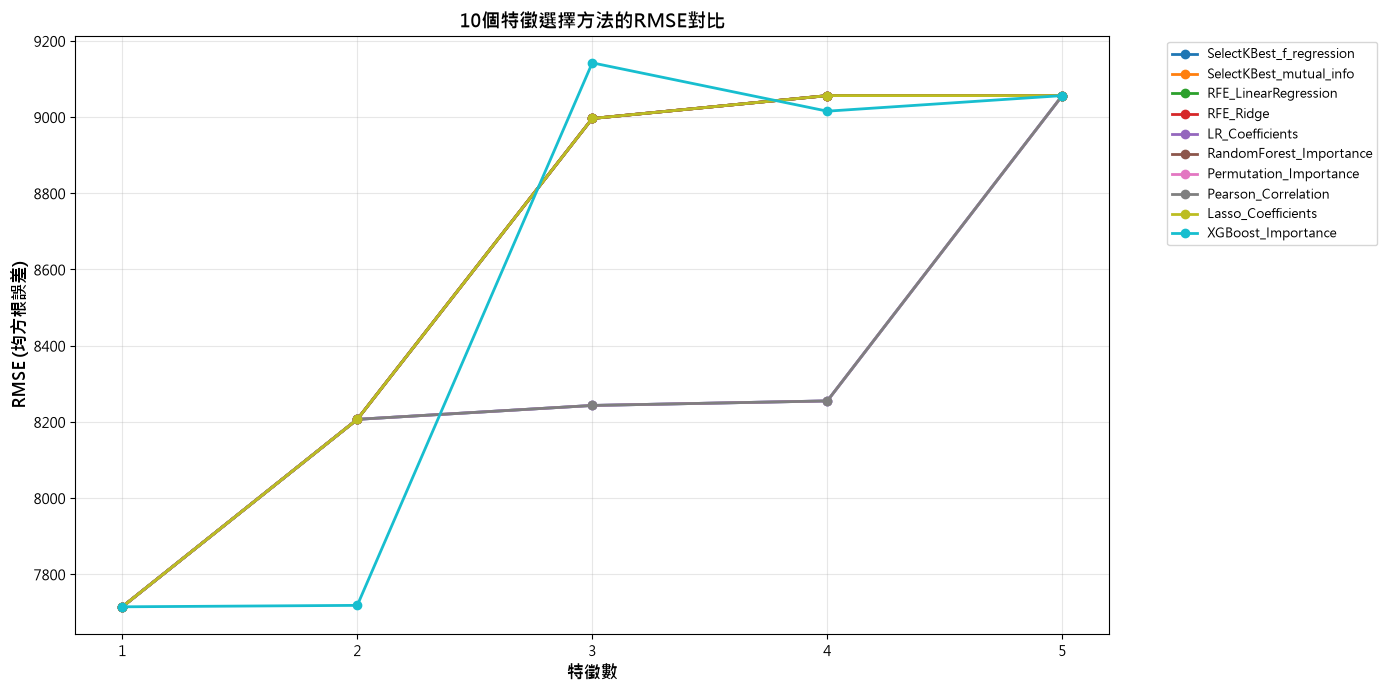

✓ 已保存: rmse_comparison.png


In [17]:
# 圖表1: RMSE vs 特徵數
# --- 關鍵設定開始 ---
# 1. 設定中文字型（以微軟正黑體為例，Mac 請換成 'Arial Unicode MS'）
plt.rcParams['font.family'] = 'Microsoft JhengHei'

# 2. 解決座標軸負號「-」顯示為方塊的問題
plt.rcParams['axes.unicode_minus'] = False
# --- 關鍵設定結束 ---
plt.figure(figsize=(14, 7))
for method in method_names:
    plt.plot(plot_data[method]['features'], plot_data[method]['rmse'],
             marker='o', label=method, linewidth=2)

plt.xlabel('特徵數', fontsize=12, fontweight='bold')
plt.ylabel('RMSE (均方根誤差)', fontsize=12, fontweight='bold')
plt.title('10個特徵選擇方法的RMSE對比', fontsize=14, fontweight='bold')
plt.xticks(range(1, 6))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rmse_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ 已保存: rmse_comparison.png")

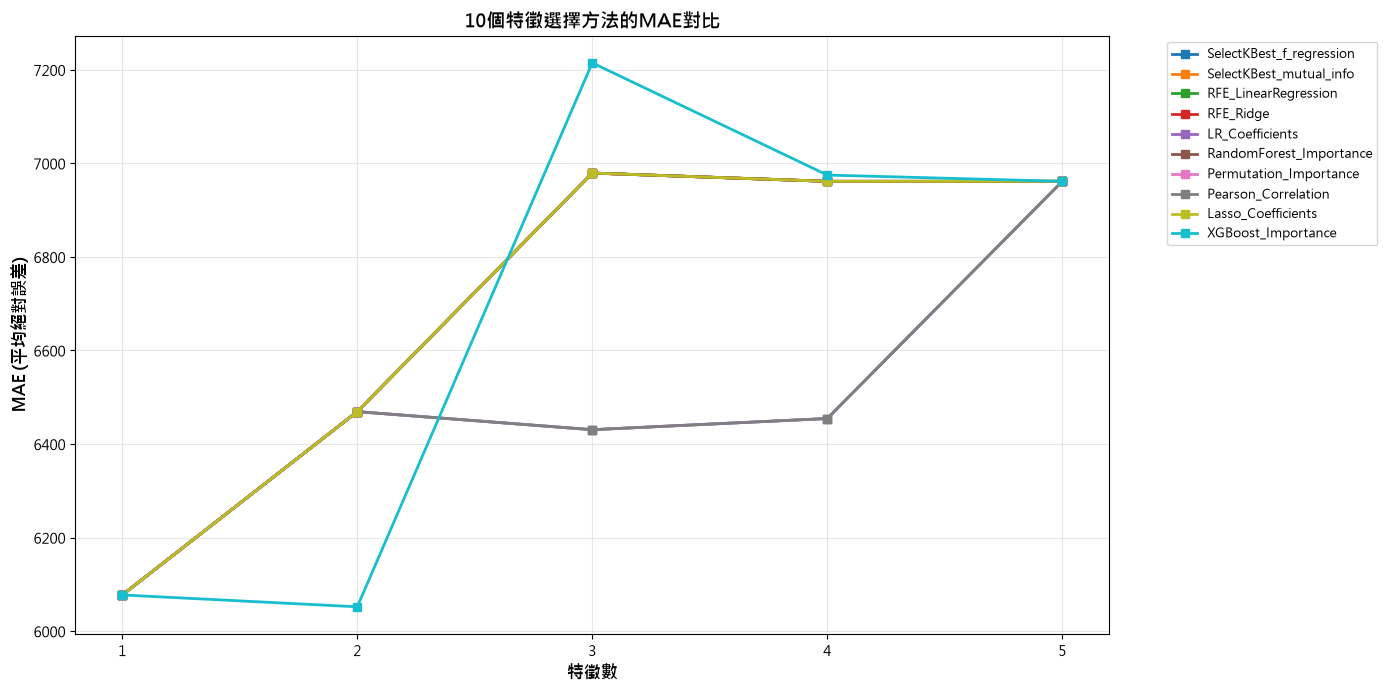

✓ 已保存: mae_comparison.png


In [18]:
# 圖表2: MAE vs 特徵數
plt.figure(figsize=(14, 7))
for method in method_names:
    plt.plot(plot_data[method]['features'], plot_data[method]['mae'],
             marker='s', label=method, linewidth=2)

plt.xlabel('特徵數', fontsize=12, fontweight='bold')
plt.ylabel('MAE (平均絕對誤差)', fontsize=12, fontweight='bold')
plt.title('10個特徵選擇方法的MAE對比', fontsize=14, fontweight='bold')
plt.xticks(range(1, 6))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mae_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ 已保存: mae_comparison.png")

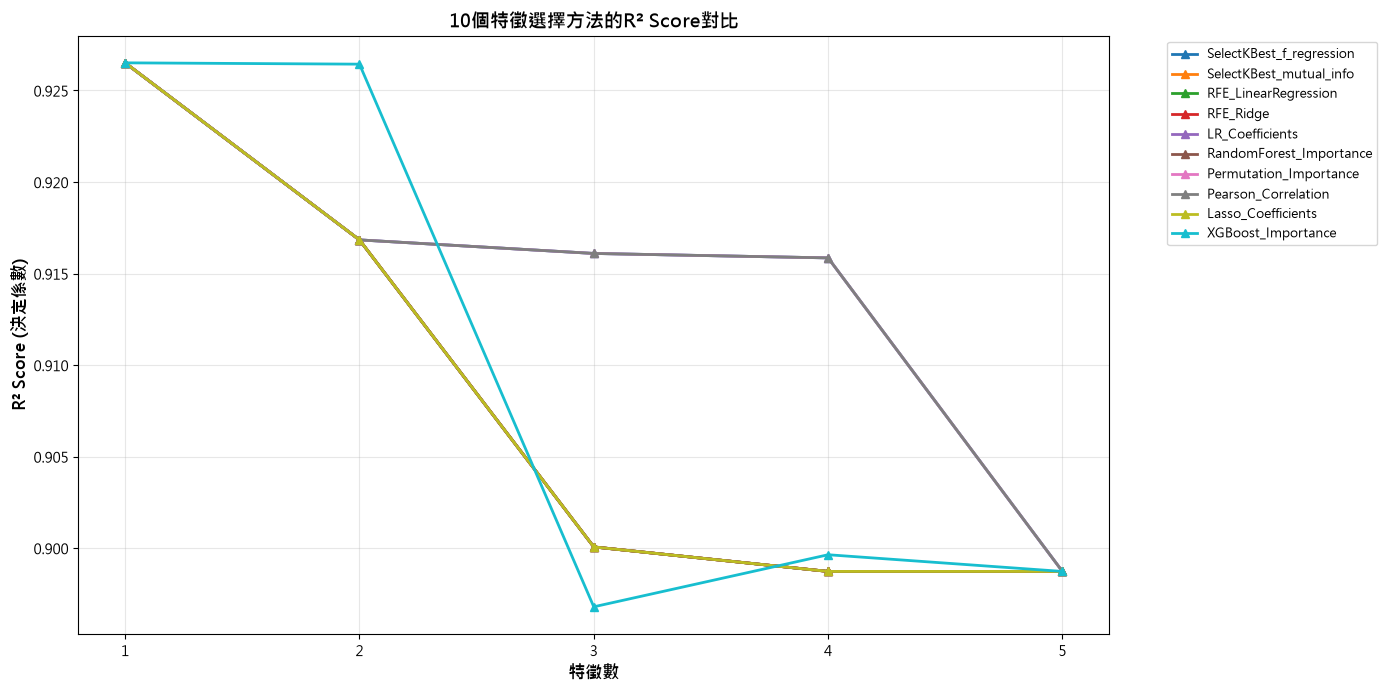

✓ 已保存: r2_comparison.png


In [19]:
# 圖表3: R² Score vs 特徵數
plt.figure(figsize=(14, 7))
for method in method_names:
    plt.plot(plot_data[method]['features'], plot_data[method]['r2'],
             marker='^', label=method, linewidth=2)

plt.xlabel('特徵數', fontsize=12, fontweight='bold')
plt.ylabel('R² Score (決定係數)', fontsize=12, fontweight='bold')
plt.title('10個特徵選擇方法的R² Score對比', fontsize=14, fontweight='bold')
plt.xticks(range(1, 6))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('r2_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ 已保存: r2_comparison.png")

## 6. 部署與總結

In [20]:
# 找出最佳性能的特徵組合
print("=" * 70)
print("最佳性能分析")
print("=" * 70)

best_r2_idx = results_df['R2_Score'].idxmax()
best_rmse_idx = results_df['RMSE'].idxmin()
best_mae_idx = results_df['MAE'].idxmin()

print("\n最高R² Score:")
print(results_df.loc[best_r2_idx])
print("\n最低RMSE:")
print(results_df.loc[best_rmse_idx])
print("\n最低MAE:")
print(results_df.loc[best_mae_idx])

最佳性能分析

最高R² Score:
Method               SelectKBest_f_regression
Num_Features                                1
Selected_Features                   R&D Spend
R2_Score                             0.926511
RMSE                              7714.334891
MAE                               6077.363301
Name: 0, dtype: object

最低RMSE:
Method               SelectKBest_f_regression
Num_Features                                1
Selected_Features                   R&D Spend
R2_Score                             0.926511
RMSE                              7714.334891
MAE                               6077.363301
Name: 0, dtype: object

最低MAE:
Method                      XGBoost_Importance
Num_Features                                 2
Selected_Features    R&D Spend, State_New York
R2_Score                              0.926439
RMSE                               7718.101892
MAE                                6052.031363
Name: 46, dtype: object


In [21]:
# 訓練最佳模型並保存
import pickle

best_method = results_df.loc[best_r2_idx, 'Method']
best_num_features = results_df.loc[best_r2_idx, 'Num_Features']
best_features = results_df.loc[best_r2_idx, 'Selected_Features'].split(', ')

print(f"\n最佳模型參數:")
print(f"  方法: {best_method}")
print(f"  特徵數: {best_num_features}")
print(f"  特徵: {best_features}")

# 訓練最佳模型
X_train_best = X_train_scaled[best_features]
X_test_best = X_test_scaled[best_features]

best_model = LinearRegression()
best_model.fit(X_train_best, y_train)
y_pred_best = best_model.predict(X_test_best)

print(f"\n最佳模型性能:")
print(f"  R² Score: {r2_score(y_test, y_pred_best):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_best):.2f}")

# 保存最佳模型
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# 保存縮放器和特徵列表
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('best_features.pkl', 'wb') as f:
    pickle.dump(best_features, f)

print("\n✓ 已保存: best_model.pkl, scaler.pkl, best_features.pkl")


最佳模型參數:
  方法: SelectKBest_f_regression
  特徵數: 1
  特徵: ['R&D Spend']

最佳模型性能:
  R² Score: 0.9265
  RMSE: 7714.33
  MAE: 6077.36

✓ 已保存: best_model.pkl, scaler.pkl, best_features.pkl


In [22]:
# 最終總結
print("\n" + "=" * 70)
print("CRISP-DM分析完成")
print("=" * 70)
print("\n輸出文件清單:")
print("  1. feature_selection_results.csv - 50個結果（10方法×5特徵數）")
print("  2. feature_priority_ranking.csv - 10個方法的特徵優先順序表")
print("  3. rmse_comparison.png - RMSE vs 特徵數折線圖")
print("  4. mae_comparison.png - MAE vs 特徵數折線圖")
print("  5. r2_comparison.png - R² vs 特徵數折線圖")
print("  6. best_model.pkl - 最佳訓練模型")
print("  7. scaler.pkl - 特徵標準化縮放器")
print("  8. best_features.pkl - 最佳特徵列表")
print("\n分析統計:")
print(f"  • 總特徵數: {len(feature_names)}")
print(f"  • 特徵選擇方法: 10個")
print(f"  • 每個方法的特徵數組合: 1-5個")
print(f"  • 訓練的MLR模型數: {len(results_df)}個")
print(f"  • 評估指標: R², RMSE, MAE")
print(f"\n數據集:")
print(f"  • 訓練樣本: {X_train.shape[0]}")
print(f"  • 測試樣本: {X_test.shape[0]}")
print("\n完成時間: 2026-06-12")


CRISP-DM分析完成

輸出文件清單:
  1. feature_selection_results.csv - 50個結果（10方法×5特徵數）
  2. feature_priority_ranking.csv - 10個方法的特徵優先順序表
  3. rmse_comparison.png - RMSE vs 特徵數折線圖
  4. mae_comparison.png - MAE vs 特徵數折線圖
  5. r2_comparison.png - R² vs 特徵數折線圖
  6. best_model.pkl - 最佳訓練模型
  7. scaler.pkl - 特徵標準化縮放器
  8. best_features.pkl - 最佳特徵列表

分析統計:
  • 總特徵數: 5
  • 特徵選擇方法: 10個
  • 每個方法的特徵數組合: 1-5個
  • 訓練的MLR模型數: 50個
  • 評估指標: R², RMSE, MAE

數據集:
  • 訓練樣本: 40
  • 測試樣本: 10

完成時間: 2026-06-12
